# Riesgo de Crédito: NN robusta + baseline clásico + SHAP

Este notebook:
- Entrena una red neuronal con random search.
- Compara con un modelo clásico de referencia (Random Forest).
- Aplica SHAP sobre la mejor NN.


In [1]:
# Instalaci?n opcional en Colab (descomenta si hace falta)
# !pip -q install -U tensorflow scikit-learn pandas numpy shap matplotlib

In [2]:
# Montar Google Drive si tu CSV est? all? (opcional)
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/ruta/loan.csv'

In [3]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import ParameterSampler, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow:', tf.__version__)
print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1781456039.576405    5075 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781456039.608955    5075 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781456040.654184    5075 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPUs disponibles: []


E0000 00:00:1781456042.002042    5075 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
@dataclass
class SearchResult:
    trial: int
    params: Dict[str, Any]
    best_val_pr_auc: float


class CreditRiskNNRandomSearch:
    """
    Random search para red neuronal de riesgo de crédito.

    Restricciones solicitadas:
    - Activación oculta: relu
    - Optimizador: adam
    """

    def __init__(
        self,
        target_col: str = 'loan_status',
        features: List[str] | None = None,
        random_state: int = 42,
        model_dir: str = 'artifacts',
    ) -> None:
        self.target_col = target_col
        self.features = features
        self.random_state = random_state
        self.model_dir = Path(model_dir)
        self.model_dir.mkdir(parents=True, exist_ok=True)

        self.preprocessor: ColumnTransformer | None = None
        self.best_model: tf.keras.Model | None = None
        self.best_params: Dict[str, Any] | None = None
        self.history_: tf.keras.callbacks.History | None = None
        self.search_results_: List[SearchResult] = []

        self.X_train_t = None
        self.X_val_t = None
        self.X_test_t = None
        self.y_train_arr = None
        self.y_val_arr = None
        self.y_test_arr = None
        self.feature_names_ = None
        self.best_threshold_ = 0.5

    def _set_seed(self) -> None:
        os.environ['PYTHONHASHSEED'] = str(self.random_state)
        random.seed(self.random_state)
        np.random.seed(self.random_state)
        tf.random.set_seed(self.random_state)

    def _load_data(self, csv_path: str) -> Tuple[pd.DataFrame, pd.Series]:
        df = pd.read_csv(csv_path)

        if self.target_col not in df.columns:
            raise ValueError(f"No se encontró la columna objetivo '{self.target_col}'.")

        if 'Unnamed: 0' in df.columns:
            df = df.drop(columns=['Unnamed: 0'])

        y = df[self.target_col].astype(int)

        # Si se definieron features, usamos exactamente esas (como en Untitled16)
        if self.features is not None:
            missing = [c for c in self.features if c not in df.columns]
            if missing:
                raise ValueError(f'Faltan columnas en CSV: {missing}')
            X = df[self.features].copy()
        else:
            X = df.drop(columns=[self.target_col])

        return X, y

    def _build_preprocessor(self, X: pd.DataFrame) -> ColumnTransformer:
        numeric_cols = X.select_dtypes(include=['number', 'bool']).columns.tolist()
        categorical_cols = [c for c in X.columns if c not in numeric_cols]

        numeric_pipe = Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]
        )

        categorical_pipe = Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ]
        )

        return ColumnTransformer(
            transformers=[
                ('num', numeric_pipe, numeric_cols),
                ('cat', categorical_pipe, categorical_cols),
            ]
        )

    def _regularizer_from_params(self, params: Dict[str, Any]):
        reg_type = params['regularization_type']
        reg_strength = params['regularization_strength']

        if reg_type == 'none':
            return None
        if reg_type == 'l1':
            return tf.keras.regularizers.l1(reg_strength)
        if reg_type == 'l2':
            return tf.keras.regularizers.l2(reg_strength)
        if reg_type == 'l1_l2':
            return tf.keras.regularizers.l1_l2(l1=reg_strength, l2=reg_strength)

        raise ValueError(f'Tipo de regularización no soportado: {reg_type}')

    def _make_model(self, input_dim: int, params: Dict[str, Any]) -> tf.keras.Model:
        reg = self._regularizer_from_params(params)
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(input_dim,)))

        # Arquitectura robusta: bloques densos + batch norm + dropout + ruido gaussiano
        if params['gaussian_noise_std'] > 0:
            model.add(tf.keras.layers.GaussianNoise(params['gaussian_noise_std']))

        units = params['units']
        for layer_idx in range(params['num_layers']):
            layer_units = max(16, int(units * (params['layer_shrink_factor'] ** layer_idx)))
            model.add(
                tf.keras.layers.Dense(
                    layer_units,
                    activation='relu',
                    kernel_regularizer=reg,
                )
            )
            if params['batch_norm']:
                model.add(tf.keras.layers.BatchNormalization())
            if params['dropout'] > 0:
                model.add(tf.keras.layers.Dropout(params['dropout']))

        model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

        # Solo ADAM (solicitado)
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=params['learning_rate'],
            beta_1=params['beta_1'],
            beta_2=params['beta_2'],
            epsilon=params['epsilon'],
            clipnorm=params['clipnorm'],
        )

        model.compile(
            optimizer=optimizer,
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=params['label_smoothing']),
            metrics=[
                tf.keras.metrics.AUC(name='roc_auc', curve='ROC'),
                tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
            ],
        )
        return model

    def _class_weight(self, y_train: np.ndarray) -> Dict[int, float]:
        classes = np.array([0, 1])
        weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
        return {0: float(weights[0]), 1: float(weights[1])}

    def random_search(
        self,
        csv_path: str,
        n_trials: int = 25,
        test_size: float = 0.2,
        val_size: float = 0.2,
        max_epochs: int = 60,
    ) -> None:
        self._set_seed()
        X, y = self._load_data(csv_path)

        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=self.random_state
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=val_size, stratify=y_train_full, random_state=self.random_state
        )

        self.preprocessor = self._build_preprocessor(X_train)
        X_train_t = self.preprocessor.fit_transform(X_train)
        X_val_t = self.preprocessor.transform(X_val)
        X_test_t = self.preprocessor.transform(X_test)

        X_train_t = np.asarray(X_train_t, dtype=np.float32)
        X_val_t = np.asarray(X_val_t, dtype=np.float32)
        X_test_t = np.asarray(X_test_t, dtype=np.float32)

        y_train_arr = y_train.to_numpy(dtype=np.float32)
        y_val_arr = y_val.to_numpy(dtype=np.float32)
        y_test_arr = y_test.to_numpy(dtype=np.float32)

        self.X_train_t, self.X_val_t, self.X_test_t = X_train_t, X_val_t, X_test_t
        self.y_train_arr, self.y_val_arr, self.y_test_arr = y_train_arr, y_val_arr, y_test_arr
        self.feature_names_ = self.preprocessor.get_feature_names_out()

        cw = self._class_weight(y_train_arr.astype(int))

        # Búsqueda robusta manteniendo ADAM + ReLU fijos
        search_space = {
            'num_layers': [2, 3, 4, 5],
            'units': [64, 128, 256, 384],
            'layer_shrink_factor': [1.0, 0.75, 0.6],
            'dropout': [0.1, 0.2, 0.3, 0.4, 0.5],
            'batch_norm': [True, False],
            'gaussian_noise_std': [0.0, 0.01, 0.03, 0.05],
            'regularization_type': ['none', 'l1', 'l2', 'l1_l2'],
            'regularization_strength': [1e-6, 1e-5, 1e-4, 5e-4, 1e-3],
            'learning_rate': [1e-4, 3e-4, 7e-4, 1e-3, 2e-3],
            'beta_1': [0.85, 0.9, 0.95],
            'beta_2': [0.99, 0.995, 0.999],
            'epsilon': [1e-8, 1e-7],
            'clipnorm': [None, 0.5, 1.0, 2.0],
            'label_smoothing': [0.0, 0.01, 0.03, 0.05],
            'batch_size': [128, 256, 512, 1024],
        }

        sampled_params = list(ParameterSampler(search_space, n_iter=n_trials, random_state=self.random_state))

        best_pr_auc = -np.inf

        for trial, params in enumerate(sampled_params, start=1):
            print(f'\nTrial {trial}/{n_trials} | params={params}')
            model = self._make_model(input_dim=X_train_t.shape[1], params=params)

            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_pr_auc', mode='max', patience=8, restore_best_weights=True
                ),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_pr_auc', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=0
                )
            ]

            history = model.fit(
                X_train_t,
                y_train_arr,
                validation_data=(X_val_t, y_val_arr),
                epochs=max_epochs,
                batch_size=params['batch_size'],
                class_weight=cw,
                verbose=0,
                callbacks=callbacks,
            )

            trial_best_pr_auc = float(np.max(history.history['val_pr_auc']))
            self.search_results_.append(SearchResult(trial=trial, params=params, best_val_pr_auc=trial_best_pr_auc))
            print(f'Best val PR-AUC en este trial: {trial_best_pr_auc:.5f}')

            if trial_best_pr_auc > best_pr_auc:
                best_pr_auc = trial_best_pr_auc
                self.best_model = model
                self.best_params = params
                self.history_ = history

        if self.best_model is None or self.best_params is None:
            raise RuntimeError('No se entrenó ningún modelo en random search.')

        print('\nMejores hiperparámetros:')
        print(self.best_params)

        val_scores = self.best_model.predict(X_val_t, verbose=0).ravel()
        test_scores = self.best_model.predict(X_test_t, verbose=0).ravel()

        val_pr_auc = average_precision_score(y_val_arr, val_scores)
        test_pr_auc = average_precision_score(y_test_arr, test_scores)
        print(f'Validation PR-AUC (NN): {val_pr_auc:.5f}')
        print(f'Test PR-AUC (NN):       {test_pr_auc:.5f}')

        precision, recall, thresholds = precision_recall_curve(y_val_arr, val_scores)
        f2 = (5 * precision * recall) / (4 * precision + recall + 1e-12)
        best_idx = int(np.nanargmax(f2))
        tuned_threshold = 0.5 if best_idx >= len(thresholds) else float(thresholds[best_idx])
        self.best_threshold_ = tuned_threshold

        print(f'Umbral elegido (máximo F2 en validación): {tuned_threshold:.5f}')

        test_pred = (test_scores >= tuned_threshold).astype(int)
        print('\nReporte de clasificación (NN, test):')
        print(classification_report(y_test_arr.astype(int), test_pred, digits=4))

        self.best_model.save(self.model_dir / 'best_credit_risk_nn.keras')
        print(f"Modelo guardado en: {self.model_dir / 'best_credit_risk_nn.keras'}")

    def train_baseline_logistic_regression(self) -> None:
        """Modelo clasico de referencia: Regresión Logística balanceada."""
        if self.X_train_t is None:
            raise RuntimeError('Primero ejecuta random_search para preparar los datos.')

        lr = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=self.random_state,
            n_jobs=-1,
        )
        lr.fit(self.X_train_t, self.y_train_arr.astype(int))

        val_scores = lr.predict_proba(self.X_val_t)[:, 1]
        test_scores = lr.predict_proba(self.X_test_t)[:, 1]

        val_pr_auc = average_precision_score(self.y_val_arr, val_scores)
        test_pr_auc = average_precision_score(self.y_test_arr, test_scores)

        print('\nBaseline clasico: Regresión Logística')
        print(f'Validation PR-AUC (LR): {val_pr_auc:.5f}')
        print(f'Test PR-AUC (LR):       {test_pr_auc:.5f}')

        test_pred = (test_scores >= self.best_threshold_).astype(int)
        print('\nReporte de clasificación (LR, test, umbral de la NN):')
        print(classification_report(self.y_test_arr.astype(int), test_pred, digits=4))

    def explain_best_model_shap(self, background_size: int = 500, explain_size: int = 300) -> None:
        """Interpretabilidad SHAP de la mejor NN con fallback robusto de explainers."""
        if self.best_model is None:
            raise RuntimeError('No hay mejor modelo. Ejecuta random_search primero.')

        rng = np.random.default_rng(self.random_state)

        bg_idx = rng.choice(self.X_train_t.shape[0], size=min(background_size, self.X_train_t.shape[0]), replace=False)
        ex_idx = rng.choice(self.X_test_t.shape[0], size=min(explain_size, self.X_test_t.shape[0]), replace=False)

        background = self.X_train_t[bg_idx]
        x_explain = self.X_test_t[ex_idx]

        shap_values = None

        # Intento 1: DeepExplainer
        try:
            explainer = shap.DeepExplainer(self.best_model, background)
            shap_values = explainer.shap_values(x_explain)
            print('SHAP: usando DeepExplainer')
        except Exception as e1:
            print(f'DeepExplainer falló: {e1}')
            # Intento 2: GradientExplainer
            try:
                explainer = shap.GradientExplainer(self.best_model, background)
                shap_values = explainer.shap_values(x_explain)
                print('SHAP: usando GradientExplainer')
            except Exception as e2:
                print(f'GradientExplainer falló: {e2}')
                # Intento 3: KernelExplainer (más lento)
                f = lambda z: self.best_model.predict(z, verbose=0).ravel()
                small_bg = background[: min(120, background.shape[0])]
                explainer = shap.KernelExplainer(f, small_bg)
                shap_values = explainer.shap_values(x_explain[: min(120, x_explain.shape[0])], nsamples=100)
                x_explain = x_explain[: min(120, x_explain.shape[0])]
                print('SHAP: usando KernelExplainer (fallback)')

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, 0]

        print('Generando resumen global SHAP...')
        shap.summary_plot(shap_values, x_explain, feature_names=self.feature_names_, show=True)

        print('Generando gráfico de barras SHAP...')
        shap.summary_plot(shap_values, x_explain, feature_names=self.feature_names_, plot_type='bar', show=True)

    def plot_evaluation_metrics(self, images_dir: str = '../images') -> None:
        if self.best_model is None or self.history_ is None:
            raise RuntimeError('No hay modelo entrenado. Ejecuta random_search primero.')

        img_path = Path(images_dir)
        img_path.mkdir(parents=True, exist_ok=True)

        test_scores = self.best_model.predict(self.X_test_t, verbose=0).ravel()
        test_pred = (test_scores >= self.best_threshold_).astype(int)
        y_test_int = self.y_test_arr.astype(int)

        fig, ax = plt.subplots(figsize=(6, 5))
        cm = confusion_matrix(y_test_int, test_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Default (1)']).plot(ax=ax, cmap='Blues')
        ax.set_title('Matriz de Confusion (NN - Test)')
        fig.tight_layout()
        fig.savefig(img_path / 'confusion_matrix.png', dpi=150)
        plt.close(fig)
        print(f'Guardado: {img_path / "confusion_matrix.png"}')

        fpr, tpr, _ = roc_curve(y_test_int, test_scores)
        roc_auc = roc_auc_score(y_test_int, test_scores)

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'Curva ROC (NN - Test) | AUC = {roc_auc:.4f}')
        ax.legend(loc='lower right')
        fig.tight_layout()
        fig.savefig(img_path / 'roc_auc_curve.png', dpi=150)
        plt.close(fig)
        print(f'Guardado: {img_path / "roc_auc_curve.png"} | ROC-AUC = {roc_auc:.4f}')

        precision, recall, _ = precision_recall_curve(y_test_int, test_scores)
        pr_auc = average_precision_score(y_test_int, test_scores)

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'Curva Precision-Recall (NN - Test) | AP = {pr_auc:.4f}')
        ax.legend(loc='lower left')
        fig.tight_layout()
        fig.savefig(img_path / 'precision_recall_curve.png', dpi=150)
        plt.close(fig)
        print(f'Guardado: {img_path / "precision_recall_curve.png"} | PR-AUC = {pr_auc:.4f}')

        history = self.history_.history
        epochs = range(1, len(history['loss']) + 1)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(epochs, history['loss'], label='Train Loss', color='blue')
        ax.plot(epochs, history['val_loss'], label='Val Loss', color='orange')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (BinaryCrossentropy)')
        ax.set_title('Curvas de Perdida (Mejor NN)')
        ax.legend()
        fig.tight_layout()
        fig.savefig(img_path / 'loss_curves.png', dpi=150)
        plt.close(fig)
        print(f'Guardado: {img_path / "loss_curves.png"}')

        print('\nTodas las metricas guardadas correctamente.')

In [5]:
# Variables tomadas de Untitled16.ipynb
FEATURES_UNTITLED16 = [
    'last_pymnt_amnt', 'recoveries', 'out_prncp', 'int_rate',
    'term', 'total_rec_late_fee', 'tot_cur_bal',
    'dti', 'initial_list_status', 'loan_amnt'
]

# Ruta del CSV preprocesado (generado por EDA_Credit_risk.ipynb)
# Local: '../data/credit_risk_preprocessed.csv'
# Colab (Drive): '/content/drive/MyDrive/ruta/credit_risk_preprocessed.csv'
CSV_PATH = '../data/credit_risk_preprocessed.csv'
TARGET_COL = 'loan_status'

# Chequeo r?pido
df_check = pd.read_csv(CSV_PATH)
if 'Unnamed: 0' in df_check.columns:
    df_check = df_check.drop(columns=['Unnamed: 0'])

print('Shape:', df_check.shape)
print('Distribucion target:')
print(df_check[TARGET_COL].value_counts(dropna=False))
print('Tasa de default (clase 1):', (df_check[TARGET_COL] == 1).mean())
print('Columnas usadas:', FEATURES_UNTITLED16)

Shape: (190394, 33)
Distribucion target:
loan_status
0.0    146535
1.0     43859
Name: count, dtype: int64
Tasa de default (clase 1): 0.23035914997321344
Columnas usadas: ['last_pymnt_amnt', 'recoveries', 'out_prncp', 'int_rate', 'term', 'total_rec_late_fee', 'tot_cur_bal', 'dti', 'initial_list_status', 'loan_amnt']


In [6]:
# Entrenamiento NN (solo ADAM + ReLU)
runner = CreditRiskNNRandomSearch(
    target_col=TARGET_COL,
    features=FEATURES_UNTITLED16,
    random_state=42,
    model_dir='artifacts'
)

runner.random_search(
    csv_path=CSV_PATH,
    n_trials=25,   # sube/baja seg?n tiempo disponible
    test_size=0.2,
    val_size=0.2,
    max_epochs=60
)


Trial 1/25 | params={'units': 384, 'regularization_type': 'none', 'regularization_strength': 0.0001, 'num_layers': 3, 'learning_rate': 0.002, 'layer_shrink_factor': 0.6, 'label_smoothing': 0.01, 'gaussian_noise_std': 0.05, 'epsilon': 1e-08, 'dropout': 0.2, 'clipnorm': None, 'beta_2': 0.999, 'beta_1': 0.85, 'batch_size': 1024, 'batch_norm': False}
Best val PR-AUC en este trial: 0.96612

Trial 2/25 | params={'units': 64, 'regularization_type': 'l1_l2', 'regularization_strength': 0.001, 'num_layers': 3, 'learning_rate': 0.002, 'layer_shrink_factor': 0.6, 'label_smoothing': 0.05, 'gaussian_noise_std': 0.05, 'epsilon': 1e-08, 'dropout': 0.5, 'clipnorm': 0.5, 'beta_2': 0.99, 'beta_1': 0.85, 'batch_size': 512, 'batch_norm': True}
Best val PR-AUC en este trial: 0.95913

Trial 3/25 | params={'units': 256, 'regularization_type': 'l2', 'regularization_strength': 1e-06, 'num_layers': 4, 'learning_rate': 0.0007, 'layer_shrink_factor': 0.75, 'label_smoothing': 0.0, 'gaussian_noise_std': 0.01, 'epsi

In [7]:
# Baseline clásico de referencia
runner.train_baseline_logistic_regression()

/home/d0ubt/Code/credit-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Baseline clasico: Regresión Logística
Validation PR-AUC (LR): 0.95537
Test PR-AUC (LR):       0.96029

Reporte de clasificación (LR, test, umbral de la NN):
              precision    recall  f1-score   support

           0     0.9880    0.9237    0.9548     29307
           1     0.7907    0.9624    0.8681      8772

    accuracy                         0.9326     38079
   macro avg     0.8893    0.9431    0.9114     38079
weighted avg     0.9425    0.9326    0.9348     38079



Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
/home/d0ubt/Code/credit-risk/.venv/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/home/d0ubt/Code/credit-risk/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_730
Received: inputs=['Tensor(shape=(500, 10))']
  warnings.warn(msg)
/home/d0ubt/Code/credit-risk/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_730
Received: inputs=['Tensor(shape=(1000, 10))'

SHAP: usando DeepExplainer
Generando resumen global SHAP...


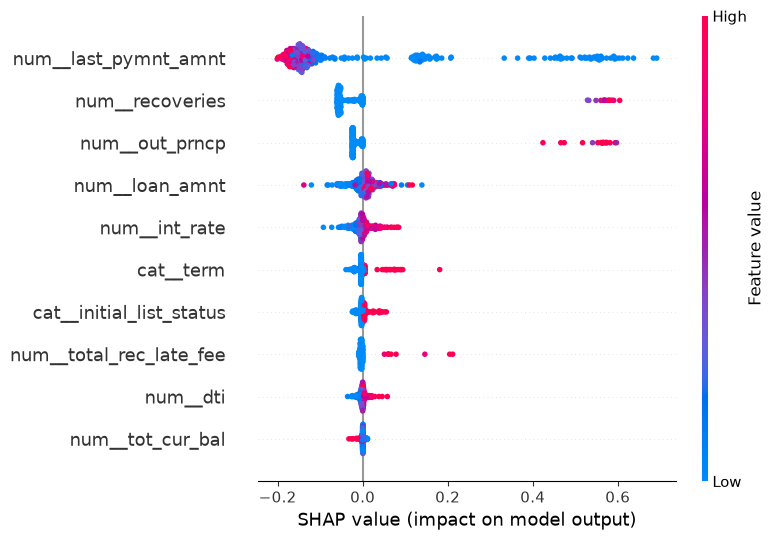

Generando gráfico de barras SHAP...


/tmp/ipykernel_5075/716892973.py:363: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_explain, feature_names=self.feature_names_, plot_type='bar', show=True)


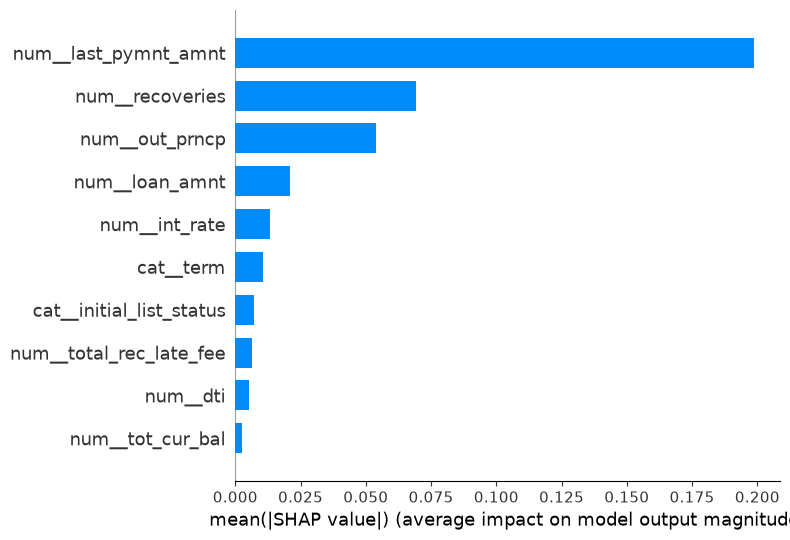

In [8]:
# SHAP de la mejor NN
runner.explain_best_model_shap(background_size=500, explain_size=300)

In [9]:
runner.plot_evaluation_metrics(images_dir='../images')

Guardado: ../images/confusion_matrix.png
Guardado: ../images/roc_auc_curve.png | ROC-AUC = 0.9943
Guardado: ../images/precision_recall_curve.png | PR-AUC = 0.9831
Guardado: ../images/loss_curves.png

Todas las metricas guardadas correctamente.


In [10]:
import joblib

# 1. Guardar el modelo en formato H5 (clásico)
h5_path = 'artifacts/best_credit_risk_nn.h5'
runner.best_model.save(h5_path)
print(f"Modelo guardado en formato H5: {h5_path}")

# 2. GUARDAR EL PREPROCESADOR (Crucial para otros entornos)
# Sin esto, no podrás transformar los datos antes de predecir
preprocessor_path = 'artifacts/preprocessor.joblib'
joblib.dump(runner.preprocessor, preprocessor_path)
print(f"Preprocesador guardado en: {preprocessor_path}")

Modelo guardado en formato H5: artifacts/best_credit_risk_nn.h5
Preprocesador guardado en: artifacts/preprocessor.joblib
